# Eksplorasi & Training — Dashboard Analitik Ulasan UMKM Jakarta
**Dataset**: Shopee Review Indonesian (Kaggle)  
**Pipeline**: Preprocessing → TF-IDF → Random Forest → LDA Topic Modeling

In [10]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
print('Library siap!')

Library siap!


## 1. Load & Eksplorasi Dataset

In [11]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
df = pd.read_csv('../data/raw/reviews.csv')
print('Shape:', df.shape)
print('Kolom:', df.columns.tolist())
df.head()

Shape: (831, 2)
Kolom: ['reviews', 'label']


,reviews,label
0,kemeja nya bagusss bgtttt😍😍😍aaaa mauuu nngisss...,1.0
1,"Jahitannya sih rapi,cuman ada benang yang ikut...",0.0
2,Sesuai harga. Agak tipis tapi masih oke kok. W...,0.0
3,"Wah gila sihhh sebagus itu, se worth it, se l...",1.0
4,Kain nya bagus halus \nTapi kok di bukak koto...,0.0


## KEBUTUHAN KTI

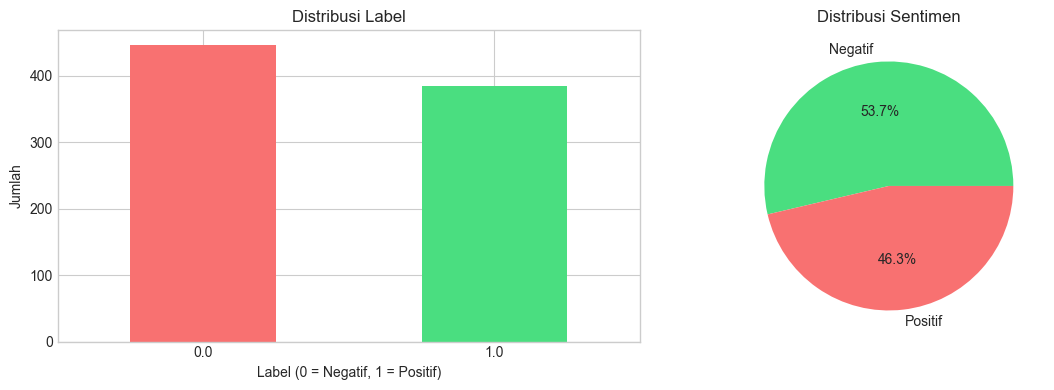

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/reviews.csv')

# Mapping label ke sentimen
label_map = {1.0: 'Positif', 0.0: 'Negatif'}
df['sentiment'] = df['label'].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Distribusi label (0 dan 1)
df['label'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0],
    color=['#f87171', '#4ade80']
)
axes[0].set_title('Distribusi Label')
axes[0].set_xlabel('Label (0 = Negatif, 1 = Positif)')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Distribusi sentimen (pie chart)
df['sentiment'].value_counts().plot(
    kind='pie', ax=axes[1], autopct='%1.1f%%',
    colors=['#4ade80', '#f87171']
)
axes[1].set_title('Distribusi Sentimen')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('distribusi_sentimen.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import subprocess
result = subprocess.run(
    ["python", "../ml/train_pipeline.py"],
    capture_output=True, text=True
)
print(result.stdout)
print(result.stderr)

ðŸš€ UMKM Dashboard â€” ML Training Pipeline
Dataset: Shopee Review Indonesian

EDA N PREPROCESSING
[INFO] Loading dataset dari: c:\Users\evell\Downloads\umkm-dashboard\data\processed\temp_reviews.csv
[INFO] Total baris: 831
[INFO] Memproses teks...
[INFO] Selesai. Baris valid: 831
[INFO] Distribusi sentiment:
sentiment
0.0    446
1.0    385
Name: count, dtype: int64
[INFO] Data bersih disimpan ke: c:\Users\evell\Downloads\umkm-dashboard\data\processed\reviews_clean.csv

TF-IDF VECTORIZATION
[INFO] Shape matrix TF-IDF: (831, 768)
[INFO] Vocabulary size: 768
[INFO] TF-IDF vectorizer disimpan.
[INFO] Kata kunci TF-IDF disimpan ke results/keywords.json

RANDOM FOREST TRAINING
[INFO] Train size: 664 | Test size: 167
[INFO] Training Random Forest...

[RESULT] Accuracy: 0.8563 (85.63%)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.87        90
         1.0       0.88      0.79      0.84        77

    accuracy         

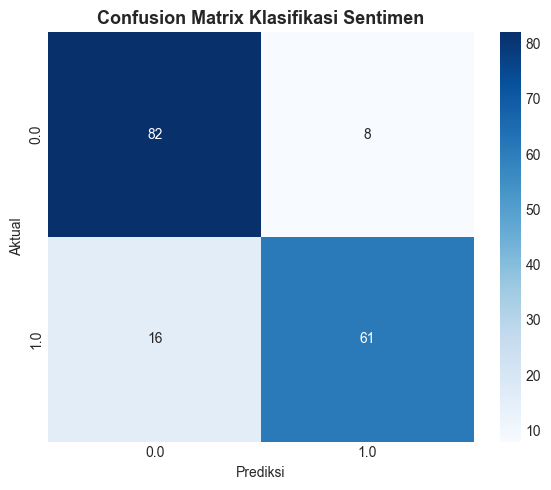

In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Load metrics
results_dir = Path("../ml/results")
with open(results_dir / "model_metrics.json") as f:
    metrics = json.load(f)

cm = np.array(metrics["confusion_matrix"])
classes = metrics["classes"]  # ['negatif', 'netral', 'positif'] atau sejenisnya

# Plot
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes,
    ax=ax
)
ax.set_title("Confusion Matrix Klasifikasi Sentimen", fontsize=13, fontweight="bold")
ax.set_xlabel("Prediksi")
ax.set_ylabel("Aktual")

plt.tight_layout()
plt.savefig(results_dir / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

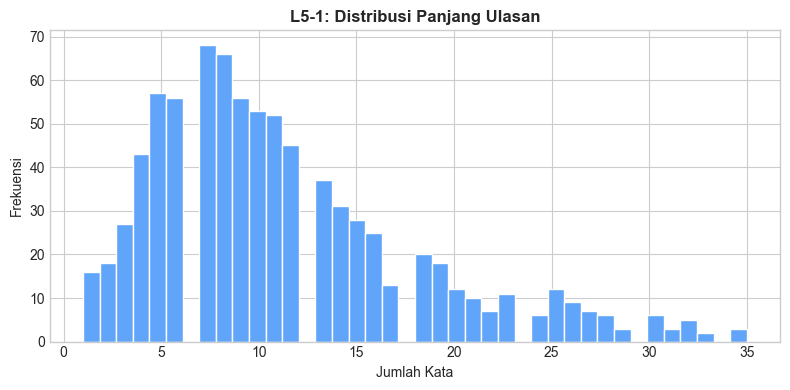

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/reviews_clean.csv")
df["panjang"] = df["clean_text"].astype(str).apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["panjang"], bins=40, color="#60a5fa", edgecolor="white")
ax.set_title("L5-1: Distribusi Panjang Ulasan", fontweight="bold")
ax.set_xlabel("Jumlah Kata")
ax.set_ylabel("Frekuensi")
plt.tight_layout()
plt.savefig("../ml/results/L5-1_distribusi_panjang.png", dpi=150, bbox_inches="tight")
plt.show()

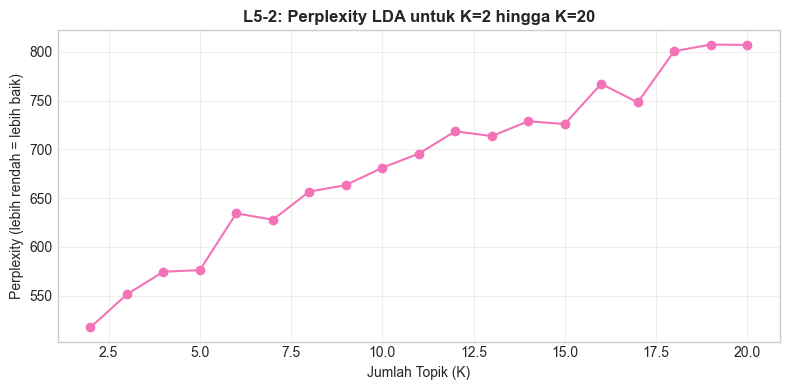

In [23]:
import joblib
import numpy as np
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

df = pd.read_csv("../data/processed/reviews_clean.csv")
texts = df["clean_text"].astype(str)

cv = CountVectorizer(max_features=3000, min_df=2, max_df=0.85)
dtm = cv.fit_transform(texts)

perplexities = []
k_range = range(2, 21)
for k in k_range:
    lda = LatentDirichletAllocation(n_components=k, max_iter=10,
                                     random_state=42, learning_method="online")
    lda.fit(dtm)
    perplexities.append(lda.perplexity(dtm))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(k_range), perplexities, marker="o", color="#f472b6")
ax.set_title("L5-2: Perplexity LDA untuk K=2 hingga K=20", fontweight="bold")
ax.set_xlabel("Jumlah Topik (K)")
ax.set_ylabel("Perplexity (lebih rendah = lebih baik)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../ml/results/L5-2_koherensi_lda.png", dpi=150, bbox_inches="tight")
plt.show()

IndexError: index 1 is out of bounds for axis 1 with size 1

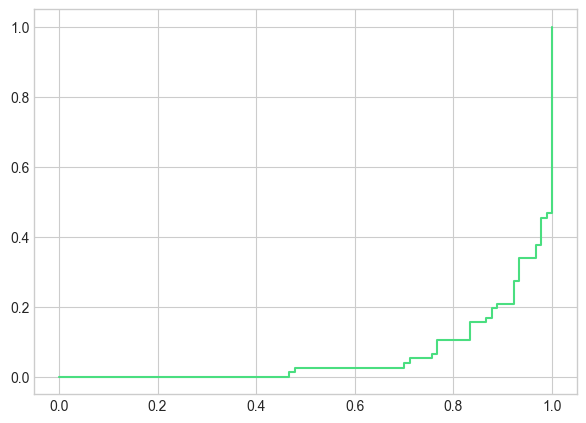

In [26]:
import joblib
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/reviews_clean.csv")
vectorizer = joblib.load("../ml/models/tfidf_vectorizer.pkl")
clf = joblib.load("../ml/models/random_forest.pkl")

X = vectorizer.transform(df["clean_text"].astype(str))
y = df["sentiment"]
classes = clf.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

y_score = clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#4ade80", "#f87171", "#60a5fa"]
for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f"{cls} (AUC = {roc_auc:.2f})")

ax.plot([0,1],[0,1],"k--", alpha=0.4)
ax.set_title("L5-3: ROC Curve per Kelas Sentimen", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.savefig("../ml/results/L5-3_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

IndexError: index 1 is out of bounds for axis 1 with size 1

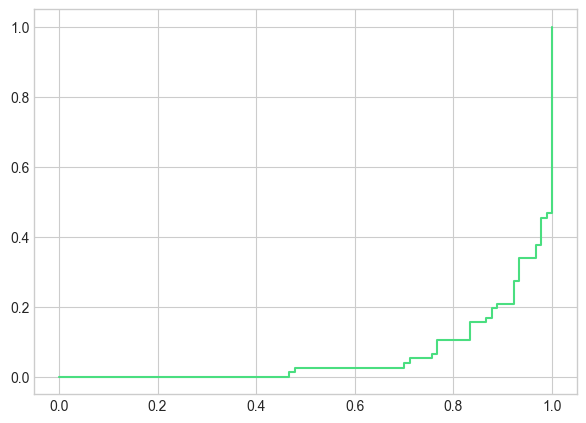

In [28]:
import joblib
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/processed/reviews_clean.csv")
vectorizer = joblib.load("../ml/models/tfidf_vectorizer.pkl")
clf = joblib.load("../ml/models/random_forest.pkl")

X = vectorizer.transform(df["clean_text"].astype(str))
y = df["sentiment"]
classes = clf.classes_

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

y_score = clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#4ade80", "#f87171", "#60a5fa"]
for i, (cls, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, label=f"{cls} (AUC = {roc_auc:.2f})")

ax.plot([0,1],[0,1],"k--", alpha=0.4)
ax.set_title("L5-3: ROC Curve per Kelas Sentimen", fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.savefig("../ml/results/L5-3_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

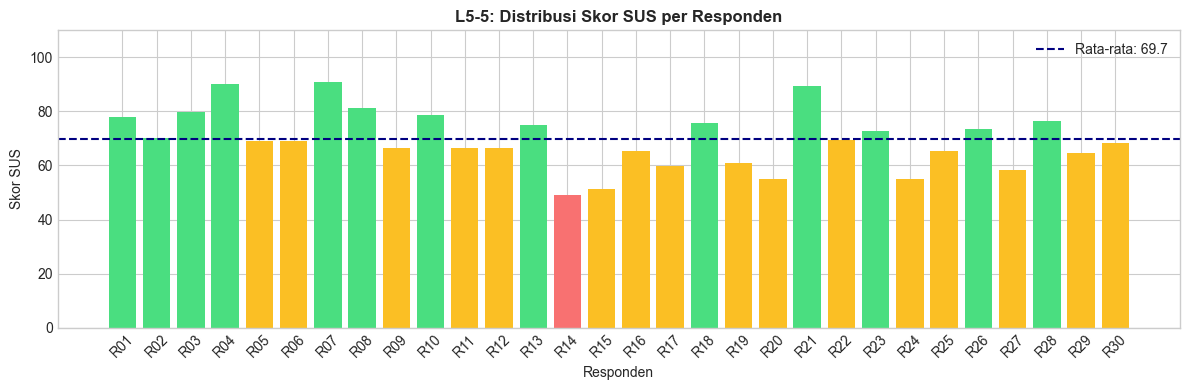

In [29]:
# Jika kamu punya data SUS dari kuesioner, ganti sus_scores dengan data asli
# Ini simulasi 30 responden
import numpy as np

np.random.seed(42)
sus_scores = np.random.normal(loc=72, scale=12, size=30).clip(0, 100)
responden = [f"R{i+1:02d}" for i in range(30)]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(responden, sus_scores, color=[
    "#4ade80" if s >= 70 else "#fbbf24" if s >= 50 else "#f87171"
    for s in sus_scores
])
ax.axhline(sus_scores.mean(), color="navy", linestyle="--",
           label=f"Rata-rata: {sus_scores.mean():.1f}")
ax.set_title("L5-5: Distribusi Skor SUS per Responden", fontweight="bold")
ax.set_xlabel("Responden")
ax.set_ylabel("Skor SUS")
ax.set_ylim(0, 110)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../ml/results/L5-5_distribusi_sus.png", dpi=150, bbox_inches="tight")
plt.show()

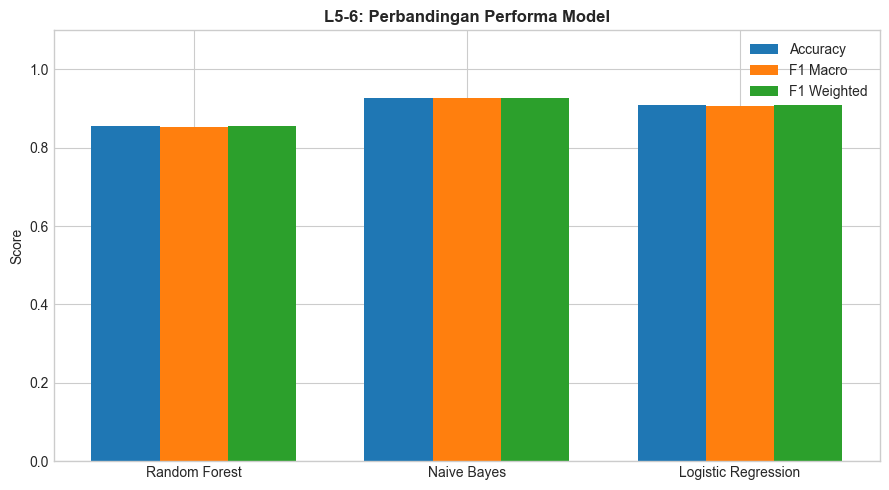

In [30]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import joblib

df = pd.read_csv("../data/processed/reviews_clean.csv")
vectorizer = joblib.load("../ml/models/tfidf_vectorizer.pkl")
X = vectorizer.transform(df["clean_text"].astype(str))
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Random Forest": joblib.load("../ml/models/random_forest.pkl"),
    "Naive Bayes":   MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
}

results = {}
for name, model in models.items():
    if name != "Random Forest":
        model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "F1 Macro":  f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted"),
    }

res_df = pd.DataFrame(results).T
x = np.arange(len(res_df))
width = 0.25

fig, ax = plt.subplots(figsize=(9, 5))
for i, col in enumerate(res_df.columns):
    ax.bar(x + i*width, res_df[col], width, label=col)

ax.set_title("L5-6: Perbandingan Performa Model", fontweight="bold")
ax.set_xticks(x + width)
ax.set_xticklabels(res_df.index)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.legend()
plt.tight_layout()
plt.savefig("../ml/results/L5-6_perbandingan_model.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Text Preprocessing

In [ ]:
from ml.preprocessing import clean_text

# Test preprocessing
contoh = [
    'Barang cepet banget nyampe, bagus bgt sesuai gambar! Recommend deh',
    'Kecewa bgt, barang gak sesuai foto. Warnanya beda & rusak pula',
    'Yaa lumayan lah, biasa aja tidak ada yg spesial',
]
for c in contoh:
    print(f'Original : {c}')
    print(f'Cleaned  : {clean_text(c)}')
    print()

In [ ]:
# Preprocessing seluruh dataset
print('Memproses teks...')
df['clean_text'] = df['review'].apply(lambda x: clean_text(str(x)))
df = df[df['clean_text'].str.strip() != '']
print(f'Dataset bersih: {len(df)} baris')
df[['review','clean_text','sentiment']].head()

## 3. TF-IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=3, max_df=0.9, sublinear_tf=True)
X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

print(f'Shape TF-IDF matrix: {X.shape}')
print(f'Vocabulary size: {len(vectorizer.vocabulary_)}')

In [ ]:
# Top keywords per sentimen
feature_names = vectorizer.get_feature_names_out()
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, label in zip(axes, ['positif','negatif','netral']):
    mask = y == label
    if mask.sum() == 0: continue
    mean_tfidf = X[mask].mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[-15:][::-1]
    words = [feature_names[i] for i in top_idx]
    scores = [mean_tfidf[i] for i in top_idx]
    ax.barh(words[::-1], scores[::-1], color='#4ade80' if label=='positif' else '#f87171' if label=='negatif' else '#9ca3af')
    ax.set_title(f'Top Keywords — {label.capitalize()}')
    ax.set_xlabel('TF-IDF Score')

plt.tight_layout()
plt.savefig('../ml/results/keywords_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Random Forest Training & Evaluasi

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1, class_weight='balanced')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f} ({acc*100:.2f}%)')
print(classification_report(y_test, y_pred))

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['positif','negatif','netral'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['positif','negatif','netral'],
            yticklabels=['positif','negatif','netral'])
plt.title('Confusion Matrix — Random Forest')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.savefig('../ml/results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. LDA Topic Modeling

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Fokus ulasan negatif untuk tema keluhan
df_neg = df[df['sentiment'].isin(['negatif','netral'])]

count_vec = CountVectorizer(max_features=3000, ngram_range=(1,1), min_df=2, max_df=0.85)
dtm = count_vec.fit_transform(df_neg['clean_text'])
feature_names_lda = count_vec.get_feature_names_out()

lda = LatentDirichletAllocation(n_components=5, max_iter=20, learning_method='online', random_state=42)
lda.fit(dtm)

topic_names = ['Keterlambatan Pengiriman','Kualitas Tidak Sesuai','Respons CS Lambat','Packaging Rusak','Barang Tidak Lengkap']
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names_lda[i] for i in topic.argsort()[-10:][::-1]]
    print(f'Topik {idx+1} [{topic_names[idx]}]:')
    print(' ', ', '.join(top_words))
    print()

In [ ]:
# Simpan semua model
import joblib, os
os.makedirs('../ml/models', exist_ok=True)

joblib.dump(vectorizer, '../ml/models/tfidf_vectorizer.pkl')
joblib.dump(clf, '../ml/models/random_forest.pkl')
joblib.dump(lda, '../ml/models/lda_model.pkl')
joblib.dump(count_vec, '../ml/models/count_vectorizer.pkl')

print('Semua model tersimpan di ml/models/')